In [14]:
import pandas as pd
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt 

In [11]:
df1 = sns.load_dataset('iris')

In [12]:
df=df1.copy()

In [13]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


# Gaussian Naive Bayes assumes:

## Feature distribution within each class is Gaussian, not the entire dataset.
## Each feature distribution within each class

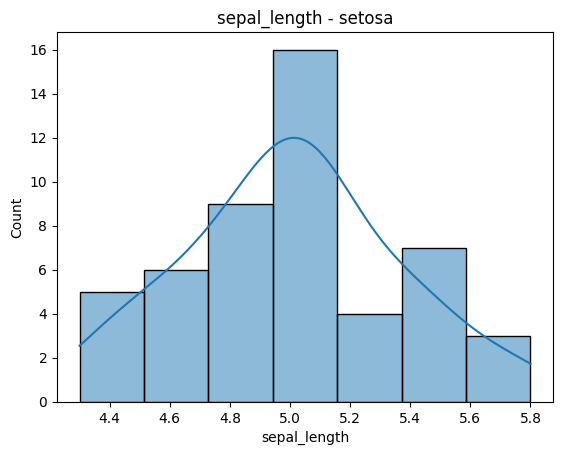

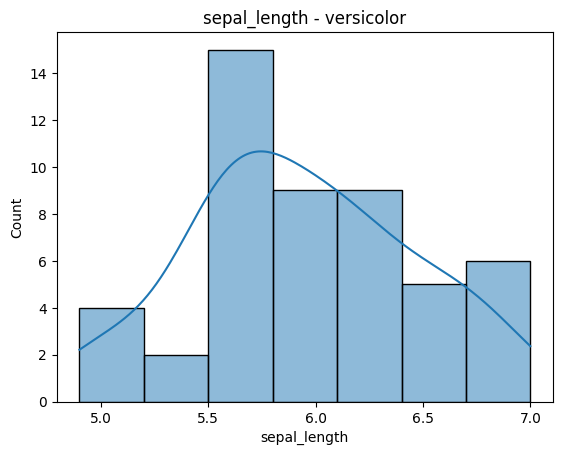

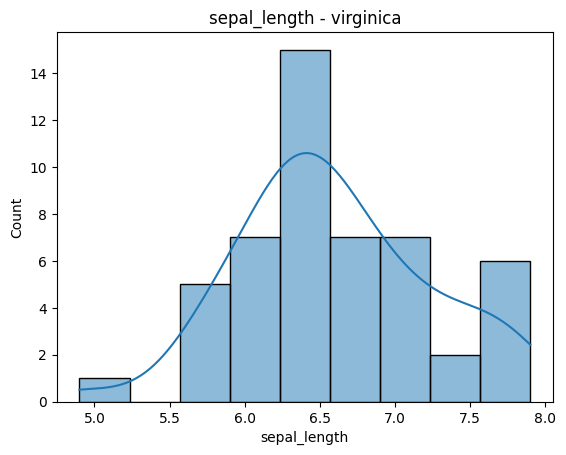

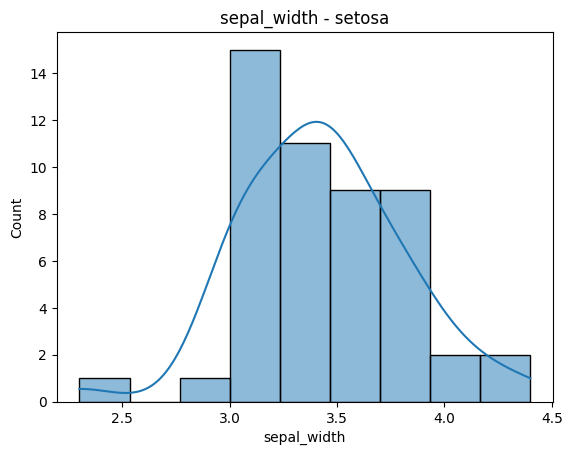

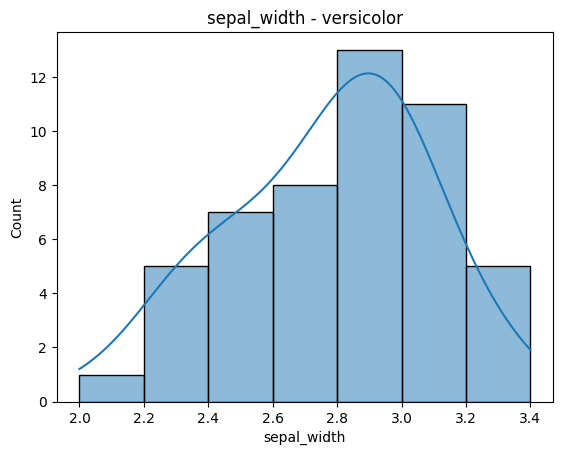

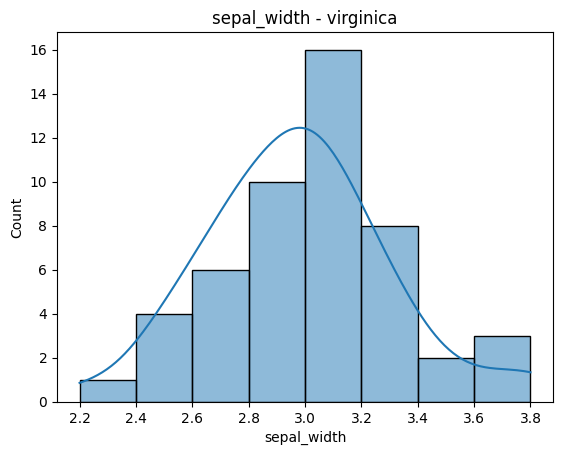

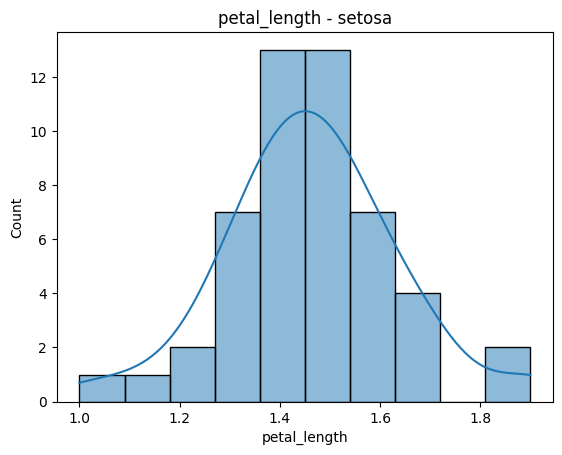

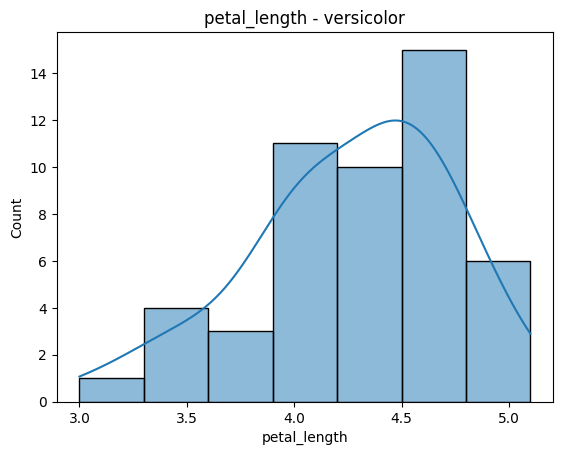

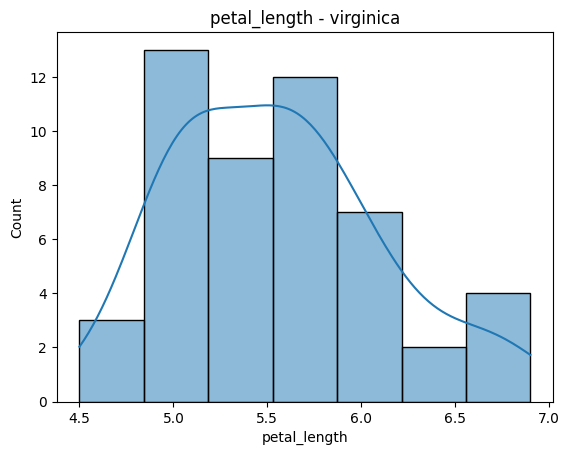

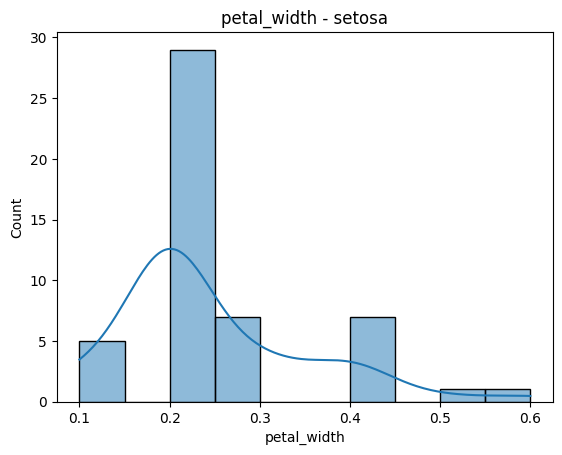

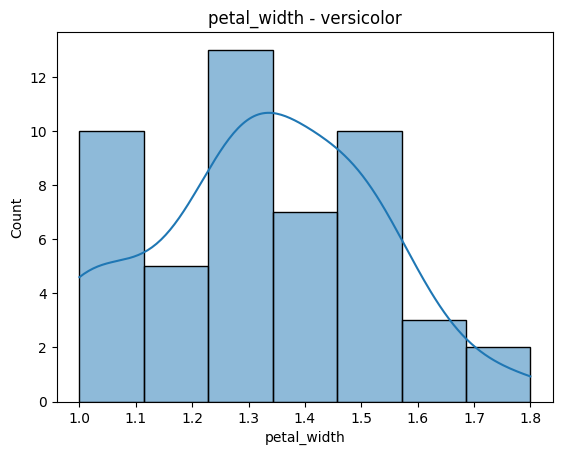

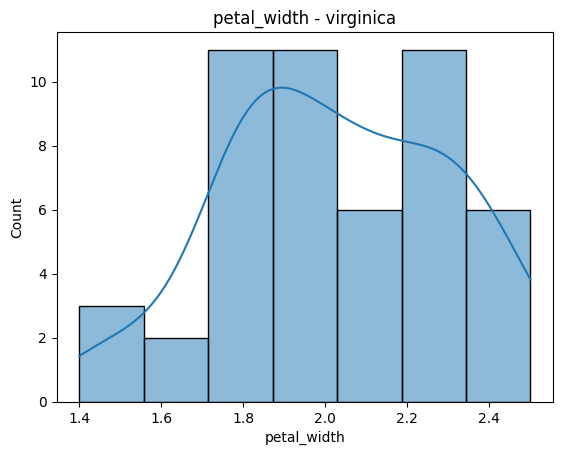

In [22]:
features = ["sepal_length","sepal_width","petal_length","petal_width"]

for feature in features:
    for species in df["species"].unique():
        sns.histplot(
            df[df["species"] == species][feature],
            kde=True
        )
        plt.title(f"{feature} - {species}")
        plt.show()

In [ ]:
X=df[["sepal_length", "sepal_width", "petal_length", "petal_width"]]
X

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [28]:
y=df['species']

In [30]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.25, random_state=42)

In [31]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()

model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [32]:
y_pred=model.predict(X_test)

In [33]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [34]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


In [35]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      1.00      1.00        11
   virginica       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



In [36]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[15  0  0]
 [ 0 11  0]
 [ 0  0 12]]


### Naive Bayes works by learning the statistical pattern of each class from the training data and then checking which class most likely produced the new input. During training, the algorithm calculates the **mean (μ)** and **standard deviation (σ)** of every feature for every class. For example, in the Iris dataset it computes the mean and standard deviation of sepal length, sepal width, petal length, and petal width separately for **Setosa, Versicolor, and Virginica**. These values describe the typical distribution of each feature within a class. When a new sample is given, the algorithm takes each feature value and evaluates **how likely that value is for each class** using the **Gaussian probability density function**. This function essentially measures **how close the input value is to the mean of that class**, where values near the mean get higher probability and values far away get lower probability. It calculates this probability for every feature and multiplies them together (because Naive Bayes assumes features are independent). The result is then multiplied by the **prior probability of the class** (how common that class is in the dataset). This produces a final score for each class. The class with the **highest probability score** is selected as the prediction. In simple terms, Naive Bayes asks: **“Which class would most likely generate these feature values?”**, and it predicts that class.


# Gaussian Naive Bayes – Important Formulas

This document summarizes the key mathematical formulas used in **Gaussian Naive Bayes classification**.

---
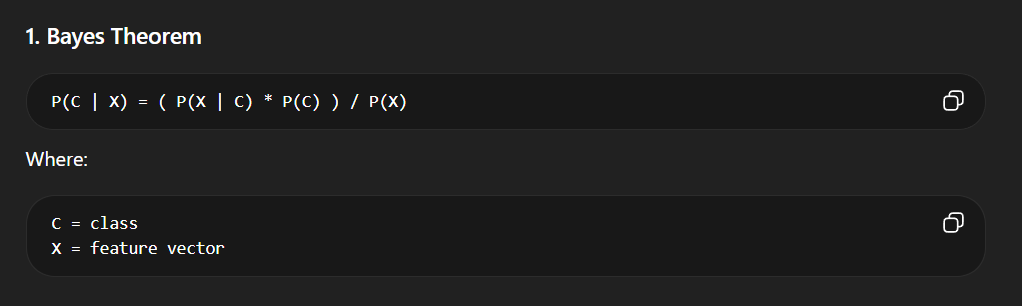

Where:
- **P(C | X)** = posterior probability  
- **P(X | C)** = likelihood  
- **P(C)** = prior probability  
- **P(X)** = evidence

---

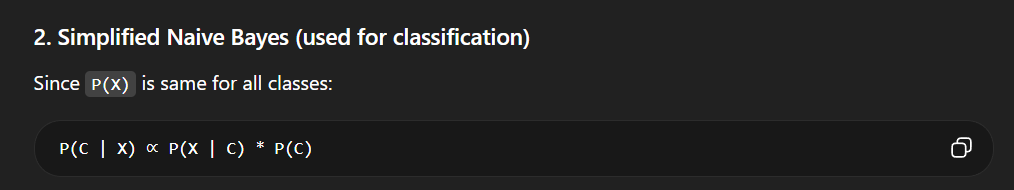
---

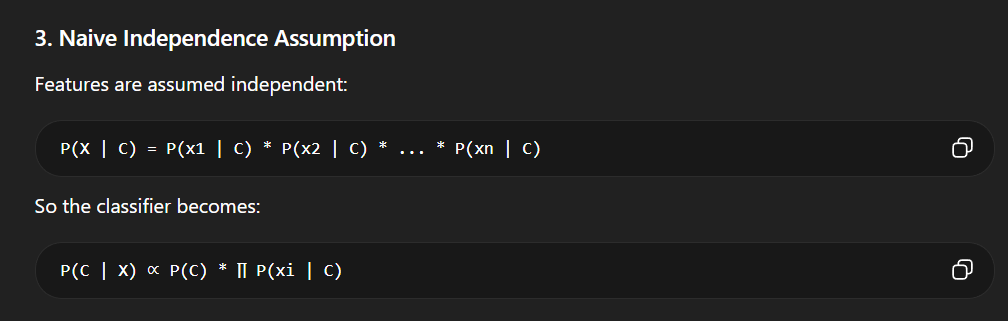

---

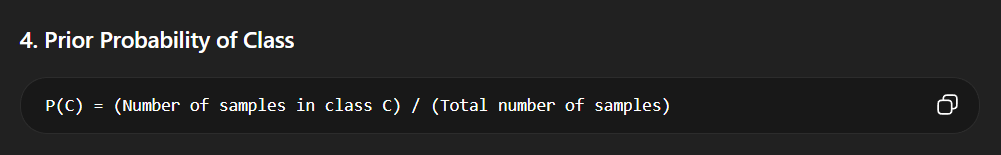

---

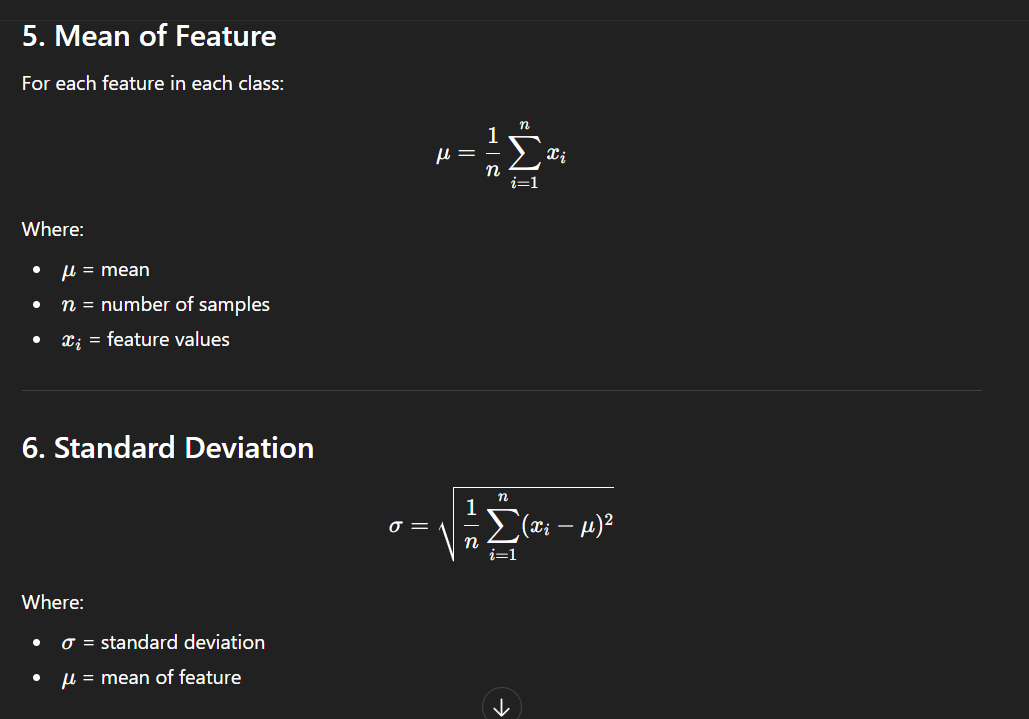
---

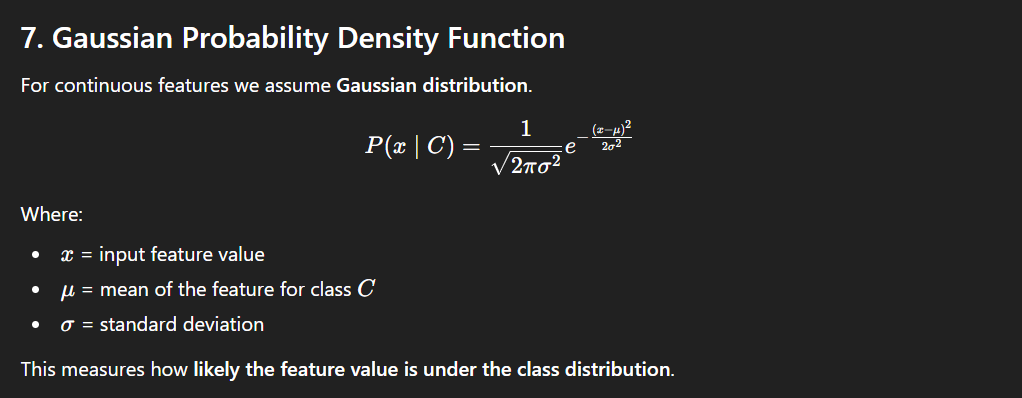
---

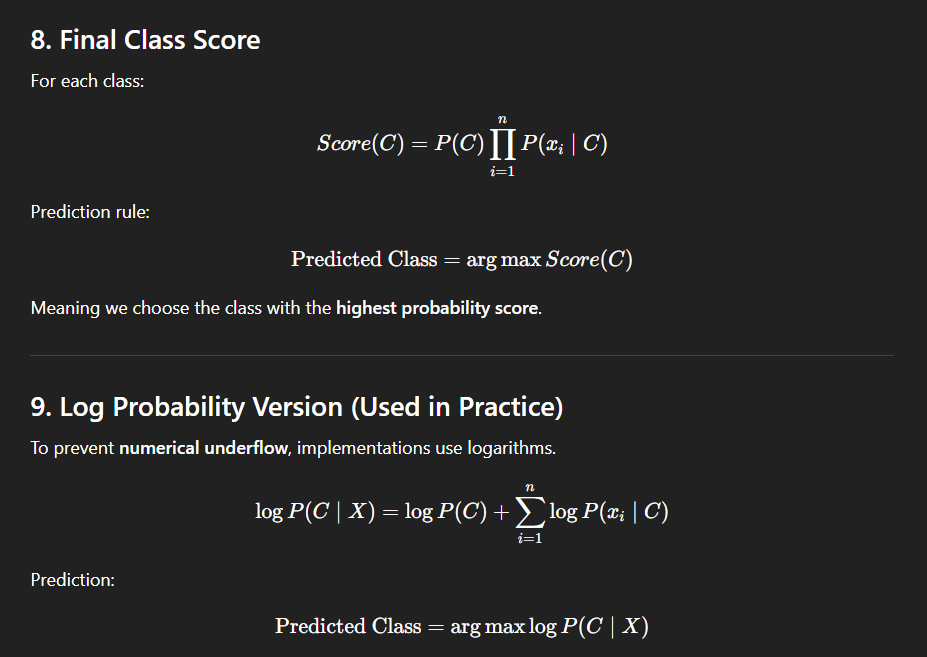
---

## Summary

Gaussian Naive Bayes works by:

1. Computing **prior probabilities of classes**
2. Calculating **mean and standard deviation of each feature for each class**
3. Using the **Gaussian probability density function** to estimate likelihood
4. Multiplying probabilities across features
5. Selecting the class with the **highest probability score**
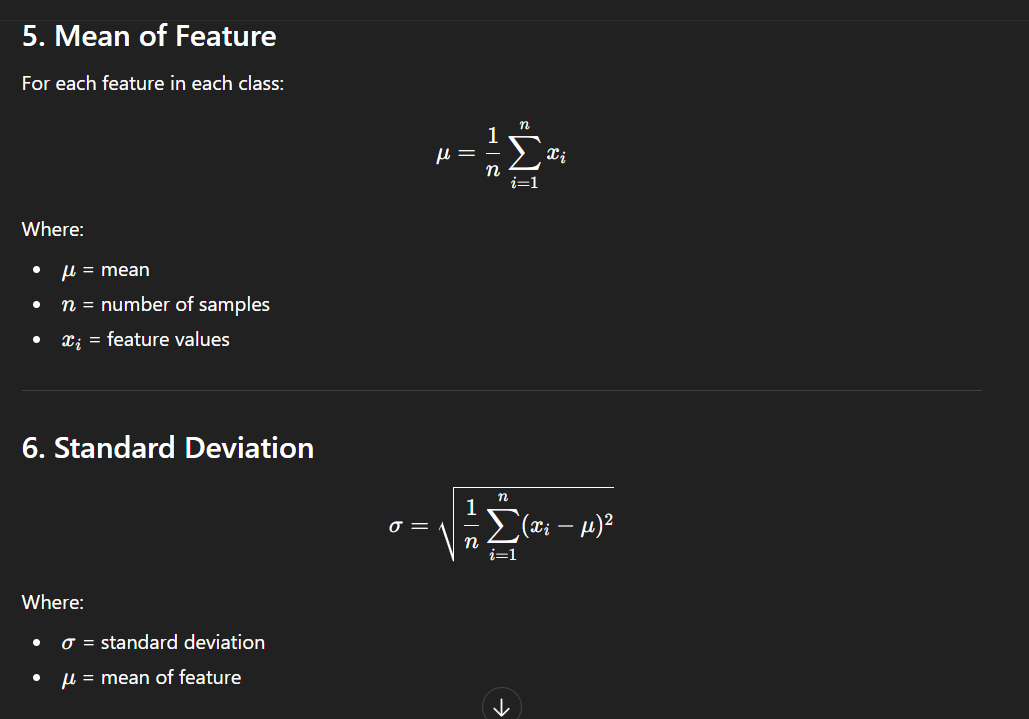